In [8]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

<h1> Load data 

In [9]:
# CMAQ lat/lon datafile
d03 = Dataset('C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc')
cmaq_lon,cmaq_lat = np.array(d03['lon']),np.array(d03['lat'])
cmaq_llat,cmaq_ulat,cmaq_llon,cmaq_ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()

In [10]:
#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

#primary roads
primary_roads = gpd.read_file('C:/Users/x12la/Desktop/Scripts/tl_2016_us_primaryroads.shp')
primary_roads = primary_roads.to_crs('EPSG:4326')

In [11]:
## Upload Aconc shapefiles
base = gpd.read_file('COMBINE_ACONC_BASE_July2023_Average_censustracts.shp')
base = base.to_crs('EPSG:4326')

idling = gpd.read_file('COMBINE_ACONC_LOCUSIdling_HDVSpatial_July2023_Average_censustracts.shp')
idling = idling.to_crs('EPSG:4326')

renewal = gpd.read_file('COMBINE_ACONC_Renewal_July2023_Average_censustracts.shp')
renewal = renewal.to_crs('EPSG:4326')

zeropre2010s =  gpd.read_file('COMBINE_ACONC_ZeroPre2010s_July2023_average_censustracts.shp')
zeropre2010s = zeropre2010s.to_crs('EPSG:4326')

In [12]:
## Upload Aconc shapefiles
base_o3 = gpd.read_file('MDA8O3_July2023_BASE_Average_censustracts.shp')
base_o3 = base_o3.to_crs('EPSG:4326')

idling_o3 = gpd.read_file('MDA8O3_July2023_LOCUSIdling_HDVSpatial_Average_censustracts.shp')
idling_o3 = idling_o3.to_crs('EPSG:4326')

renewal_o3 = gpd.read_file('MDA8O3_July2023_Renewal_Average_censustracts.shp')
renewal_o3 = renewal_o3.to_crs('EPSG:4326')

zeropre2010s_o3 =  gpd.read_file('MDA8O3_July2023_ZeroPre2010s_Average_censustracts.shp')
zeropre2010s_o3 = zeropre2010s_o3.to_crs('EPSG:4326')

In [13]:
#Clip geopandas files to CMAP
cmap_roads = gpd.clip(primary_roads, cmap_cty.to_crs('EPSG:4326'))
cmap_base = gpd.clip(base, cmap_cty.to_crs('EPSG:4326'))
cmap_idling = gpd.clip(idling, cmap_cty.to_crs('EPSG:4326'))
cmap_renewal = gpd.clip(renewal, cmap_cty.to_crs('EPSG:4326'))
cmap_zeropre2010s = gpd.clip(zeropre2010s, cmap_cty.to_crs('EPSG:4326'))

cmap_base_o3 = gpd.clip(base_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_idling_o3 = gpd.clip(idling_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_renewal_o3 = gpd.clip(renewal_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_zeropre2010s_o3 = gpd.clip(zeropre2010s_o3, cmap_cty.to_crs('EPSG:4326'))

In [14]:
# # # Load in NHGIS of the 2019-2023 ACS
demo_data = pd.read_csv('../demographic/nhgis0011_ds267_20235_tract.csv')

census_tracts = gpd.read_file('../demographic/cmap_census_tracts2018.shp')
census_tracts = census_tracts.to_crs('EPSG:4326')

demo_joined = census_tracts.merge(demo_data, on='GISJOIN')
domain_tracts = gpd.clip(census_tracts, cmap_cty.to_crs('EPSG:4326'))
domain_demo   = gpd.clip(demo_joined,  cmap_cty.to_crs('EPSG:4326'))

<h1> Merge Demographic Data

<h3>
$$
\text{Domain Total Population Weighted Average Concentrations} = \frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Population Total}_{\text{CT}})}{\sum (\text{Population Total}_{\text{CT}})}
$$


<h3>
$$
\text{Subgroup Population Weighted Average Concentrations} = \frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Subgroup Population Total}_{\text{CT}})}{\sum (\text{Subgroup Population Total}_{\text{CT}})}
$$

<h3>
$$
\text{Relative Concentrations Distributions} = \frac{(
\frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Subgroup Population Total}_{\text{CT}})}{\sum (\text{Subgroup Population Total}_{\text{CT}})})
}{
(\frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Population Total}_{\text{CT}})}{\sum (\text{Population Total}_{\text{CT}})})
}
$$


In [15]:
cmap_base['MDA8O3'] = cmap_base_o3['O3']
cmap_idling['MDA8O3'] = cmap_idling_o3['O3']
cmap_renewal['MDA8O3'] = cmap_renewal_o3['O3']
cmap_zeropre2010s['MDA8O3'] = cmap_zeropre2010s_o3['O3']

In [16]:
# ------------------------------------------------------------
# merge concentration tracts with demographic tracts
# ------------------------------------------------------------
base_joined = domain_demo.merge(cmap_base, on='GISJOIN', how='inner')
idling_joined = domain_demo.merge(cmap_idling, on='GISJOIN', how='inner')
renewal_joined = domain_demo.merge(cmap_renewal, on='GISJOIN', how='inner')
zerolegacy_joined = domain_demo.merge(cmap_zeropre2010s, on='GISJOIN', how='inner')

# ------------------------------------------------------------
# create OTHER population
# ------------------------------------------------------------
base_joined['OTHER_POP'] = (
    base_joined['ASOAE001'] - (
        base_joined['ASOAE003'] +   # NH White
        base_joined['ASOAE004'] +   # NH Black
        base_joined['ASOAE006'] +   # NH Asian
        base_joined['ASOAE012']     # Hispanic any race
    )
)

idling_joined['OTHER_POP'] = (
    idling_joined['ASOAE001'] - (
        idling_joined['ASOAE003'] +
        idling_joined['ASOAE004'] +
        idling_joined['ASOAE006'] +
        idling_joined['ASOAE012']
    )
)

renewal_joined['OTHER_POP'] = (
    renewal_joined['ASOAE001'] - (
        renewal_joined['ASOAE003'] +
        renewal_joined['ASOAE004'] +
        renewal_joined['ASOAE006'] +
        renewal_joined['ASOAE012']
    )
)

zerolegacy_joined['OTHER_POP'] = (
    zerolegacy_joined['ASOAE001'] - (
        zerolegacy_joined['ASOAE003'] +
        zerolegacy_joined['ASOAE004'] +
        zerolegacy_joined['ASOAE006'] +
        zerolegacy_joined['ASOAE012']
    )
)

In [17]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedNO2'] = (base_joined['NO2'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
idling_joined['PopWeightedNO2'] = (idling_joined['NO2'] * idling_joined['ASOAE001']).sum() / idling_joined['ASOAE001'].sum()
renewal_joined['PopWeightedNO2'] = (renewal_joined['NO2'] * renewal_joined['ASOAE001']).sum() / renewal_joined['ASOAE001'].sum()
zerolegacy_joined['PopWeightedNO2'] = (zerolegacy_joined['NO2'] * zerolegacy_joined['ASOAE001']).sum() / zerolegacy_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_PopWeightedNO2'] = (df['NO2'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedNO2'] = (df['NO2'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedNO2'] = (df['NO2'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedNO2'] = (df['NO2'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedNO2'] = (df['NO2'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative Distributions
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_RelNO2'] = df['White_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Black_RelNO2'] = df['Black_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Hispanic_RelNO2'] = df['Hispanic_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Asian_RelNO2'] = df['Asian_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Other_RelNO2'] = df['Other_PopWeightedNO2'] / df['PopWeightedNO2']

# ------------------------------------------------------------
# absolute Distributions
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_AbsNO2'] = df['White_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Black_AbsNO2'] = df['Black_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Hispanic_AbsNO2'] = df['Hispanic_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Asian_AbsNO2'] = df['Asian_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Other_AbsNO2'] = df['Other_PopWeightedNO2'] - df['PopWeightedNO2']

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
no2_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedNO2'].iloc[0], base_joined['White_PopWeightedNO2'].iloc[0], base_joined['Black_PopWeightedNO2'].iloc[0], base_joined['Hispanic_PopWeightedNO2'].iloc[0], base_joined['Asian_PopWeightedNO2'].iloc[0], base_joined['Other_PopWeightedNO2'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelNO2'].iloc[0], base_joined['Black_RelNO2'].iloc[0], base_joined['Hispanic_RelNO2'].iloc[0], base_joined['Asian_RelNO2'].iloc[0], base_joined['Other_RelNO2'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsNO2'].iloc[0], base_joined['Black_AbsNO2'].iloc[0], base_joined['Hispanic_AbsNO2'].iloc[0], base_joined['Asian_AbsNO2'].iloc[0], base_joined['Other_AbsNO2'].iloc[0]],

    'Idling_PopWeighted'  : [idling_joined['PopWeightedNO2'].iloc[0], idling_joined['White_PopWeightedNO2'].iloc[0], idling_joined['Black_PopWeightedNO2'].iloc[0], idling_joined['Hispanic_PopWeightedNO2'].iloc[0], idling_joined['Asian_PopWeightedNO2'].iloc[0], idling_joined['Other_PopWeightedNO2'].iloc[0]],
    'Idling_Relative'     : [1.0, idling_joined['White_RelNO2'].iloc[0], idling_joined['Black_RelNO2'].iloc[0], idling_joined['Hispanic_RelNO2'].iloc[0], idling_joined['Asian_RelNO2'].iloc[0], idling_joined['Other_RelNO2'].iloc[0]],
    'Idling_Absolute'     : [0.0, idling_joined['White_AbsNO2'].iloc[0], idling_joined['Black_AbsNO2'].iloc[0], idling_joined['Hispanic_AbsNO2'].iloc[0], idling_joined['Asian_AbsNO2'].iloc[0], idling_joined['Other_AbsNO2'].iloc[0]],

    'Renewal_PopWeighted' : [renewal_joined['PopWeightedNO2'].iloc[0], renewal_joined['White_PopWeightedNO2'].iloc[0], renewal_joined['Black_PopWeightedNO2'].iloc[0], renewal_joined['Hispanic_PopWeightedNO2'].iloc[0], renewal_joined['Asian_PopWeightedNO2'].iloc[0], renewal_joined['Other_PopWeightedNO2'].iloc[0]],
    'Renewal_Relative'    : [1.0, renewal_joined['White_RelNO2'].iloc[0], renewal_joined['Black_RelNO2'].iloc[0], renewal_joined['Hispanic_RelNO2'].iloc[0], renewal_joined['Asian_RelNO2'].iloc[0], renewal_joined['Other_RelNO2'].iloc[0]],
    'Renewal_Absolute'    : [0.0, renewal_joined['White_AbsNO2'].iloc[0], renewal_joined['Black_AbsNO2'].iloc[0], renewal_joined['Hispanic_AbsNO2'].iloc[0], renewal_joined['Asian_AbsNO2'].iloc[0], renewal_joined['Other_AbsNO2'].iloc[0]],

    'LegacyRemoval_PopWeighted' : [zerolegacy_joined['PopWeightedNO2'].iloc[0], zerolegacy_joined['White_PopWeightedNO2'].iloc[0], zerolegacy_joined['Black_PopWeightedNO2'].iloc[0], zerolegacy_joined['Hispanic_PopWeightedNO2'].iloc[0], zerolegacy_joined['Asian_PopWeightedNO2'].iloc[0], zerolegacy_joined['Other_PopWeightedNO2'].iloc[0]],
    'LegacyRemoval_Relative'    : [1.0, zerolegacy_joined['White_RelNO2'].iloc[0], zerolegacy_joined['Black_RelNO2'].iloc[0], zerolegacy_joined['Hispanic_RelNO2'].iloc[0], zerolegacy_joined['Asian_RelNO2'].iloc[0], zerolegacy_joined['Other_RelNO2'].iloc[0]],
    'LegacyRemoval_Absolute'    : [0.0, zerolegacy_joined['White_AbsNO2'].iloc[0], zerolegacy_joined['Black_AbsNO2'].iloc[0], zerolegacy_joined['Hispanic_AbsNO2'].iloc[0], zerolegacy_joined['Asian_AbsNO2'].iloc[0], zerolegacy_joined['Other_AbsNO2'].iloc[0]]
    
}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("=== NO2 Summary ===")
print(no2_summary.round(6).to_string())

=== NO2 Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute  Renewal_PopWeighted  Renewal_Relative  Renewal_Absolute  LegacyRemoval_PopWeighted  LegacyRemoval_Relative  LegacyRemoval_Absolute
Total             7.774700       1.000000       0.000000            7.643992         1.000000         0.000000             6.874177          1.000000          0.000000                   6.672842                1.000000                0.000000
White             6.931494       0.891545      -0.843205            6.802553         0.889922        -0.841439             6.041863          0.878922         -0.832315                   5.869129                0.879555               -0.803713
Black             9.127225       1.173965       1.352525            9.030214         1.181348         1.386221             8.242920          1.199114          1.368742                   8.002103                1.199205                1.329260
Hispanic

In [18]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedPM25_TOT'] = (base_joined['PM25_TOT'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
idling_joined['PopWeightedPM25_TOT'] = (idling_joined['PM25_TOT'] * idling_joined['ASOAE001']).sum() / idling_joined['ASOAE001'].sum()
renewal_joined['PopWeightedPM25_TOT'] = (renewal_joined['PM25_TOT'] * renewal_joined['ASOAE001']).sum() / renewal_joined['ASOAE001'].sum()
zerolegacy_joined['PopWeightedPM25_TOT'] = (zerolegacy_joined['PM25_TOT'] * zerolegacy_joined['ASOAE001']).sum() / zerolegacy_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative Distributions
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_RelPM25_TOT'] = df['White_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Black_RelPM25_TOT'] = df['Black_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Hispanic_RelPM25_TOT'] = df['Hispanic_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Asian_RelPM25_TOT'] = df['Asian_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Other_RelPM25_TOT'] = df['Other_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']

# ------------------------------------------------------------
# absolute Distributions
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_AbsPM25_TOT'] = df['White_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Black_AbsPM25_TOT'] = df['Black_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Hispanic_AbsPM25_TOT'] = df['Hispanic_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Asian_AbsPM25_TOT'] = df['Asian_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Other_AbsPM25_TOT'] = df['Other_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
pm25_tot_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedPM25_TOT'].iloc[0], base_joined['White_PopWeightedPM25_TOT'].iloc[0], base_joined['Black_PopWeightedPM25_TOT'].iloc[0], base_joined['Hispanic_PopWeightedPM25_TOT'].iloc[0], base_joined['Asian_PopWeightedPM25_TOT'].iloc[0], base_joined['Other_PopWeightedPM25_TOT'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelPM25_TOT'].iloc[0], base_joined['Black_RelPM25_TOT'].iloc[0], base_joined['Hispanic_RelPM25_TOT'].iloc[0], base_joined['Asian_RelPM25_TOT'].iloc[0], base_joined['Other_RelPM25_TOT'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsPM25_TOT'].iloc[0], base_joined['Black_AbsPM25_TOT'].iloc[0], base_joined['Hispanic_AbsPM25_TOT'].iloc[0], base_joined['Asian_AbsPM25_TOT'].iloc[0], base_joined['Other_AbsPM25_TOT'].iloc[0]],

    'Idling_PopWeighted'  : [idling_joined['PopWeightedPM25_TOT'].iloc[0], idling_joined['White_PopWeightedPM25_TOT'].iloc[0], idling_joined['Black_PopWeightedPM25_TOT'].iloc[0], idling_joined['Hispanic_PopWeightedPM25_TOT'].iloc[0], idling_joined['Asian_PopWeightedPM25_TOT'].iloc[0], idling_joined['Other_PopWeightedPM25_TOT'].iloc[0]],
    'Idling_Relative'     : [1.0, idling_joined['White_RelPM25_TOT'].iloc[0], idling_joined['Black_RelPM25_TOT'].iloc[0], idling_joined['Hispanic_RelPM25_TOT'].iloc[0], idling_joined['Asian_RelPM25_TOT'].iloc[0], idling_joined['Other_RelPM25_TOT'].iloc[0]],
    'Idling_Absolute'     : [0.0, idling_joined['White_AbsPM25_TOT'].iloc[0], idling_joined['Black_AbsPM25_TOT'].iloc[0], idling_joined['Hispanic_AbsPM25_TOT'].iloc[0], idling_joined['Asian_AbsPM25_TOT'].iloc[0], idling_joined['Other_AbsPM25_TOT'].iloc[0]],

    'Renewal_PopWeighted' : [renewal_joined['PopWeightedPM25_TOT'].iloc[0], renewal_joined['White_PopWeightedPM25_TOT'].iloc[0], renewal_joined['Black_PopWeightedPM25_TOT'].iloc[0], renewal_joined['Hispanic_PopWeightedPM25_TOT'].iloc[0], renewal_joined['Asian_PopWeightedPM25_TOT'].iloc[0], renewal_joined['Other_PopWeightedPM25_TOT'].iloc[0]],
    'Renewal_Relative'    : [1.0, renewal_joined['White_RelPM25_TOT'].iloc[0], renewal_joined['Black_RelPM25_TOT'].iloc[0], renewal_joined['Hispanic_RelPM25_TOT'].iloc[0], renewal_joined['Asian_RelPM25_TOT'].iloc[0], renewal_joined['Other_RelPM25_TOT'].iloc[0]],
    'Renewal_Absolute'    : [0.0, renewal_joined['White_AbsPM25_TOT'].iloc[0], renewal_joined['Black_AbsPM25_TOT'].iloc[0], renewal_joined['Hispanic_AbsPM25_TOT'].iloc[0], renewal_joined['Asian_AbsPM25_TOT'].iloc[0], renewal_joined['Other_AbsPM25_TOT'].iloc[0]],

    'LegacyRemoval_PopWeighted' : [zerolegacy_joined['PopWeightedPM25_TOT'].iloc[0], zerolegacy_joined['White_PopWeightedPM25_TOT'].iloc[0], zerolegacy_joined['Black_PopWeightedPM25_TOT'].iloc[0], zerolegacy_joined['Hispanic_PopWeightedPM25_TOT'].iloc[0], zerolegacy_joined['Asian_PopWeightedPM25_TOT'].iloc[0], zerolegacy_joined['Other_PopWeightedPM25_TOT'].iloc[0]],
    'LegacyRemoval_Relative'    : [1.0, zerolegacy_joined['White_RelPM25_TOT'].iloc[0], zerolegacy_joined['Black_RelPM25_TOT'].iloc[0], zerolegacy_joined['Hispanic_RelPM25_TOT'].iloc[0], zerolegacy_joined['Asian_RelPM25_TOT'].iloc[0], zerolegacy_joined['Other_RelPM25_TOT'].iloc[0]],
    'LegacyRemoval_Absolute'    : [0.0, zerolegacy_joined['White_AbsPM25_TOT'].iloc[0], zerolegacy_joined['Black_AbsPM25_TOT'].iloc[0], zerolegacy_joined['Hispanic_AbsPM25_TOT'].iloc[0], zerolegacy_joined['Asian_AbsPM25_TOT'].iloc[0], zerolegacy_joined['Other_AbsPM25_TOT'].iloc[0]]

}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("\n=== PM25_TOT Summary ===")
print(pm25_tot_summary.round(6).to_string())


=== PM25_TOT Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute  Renewal_PopWeighted  Renewal_Relative  Renewal_Absolute  LegacyRemoval_PopWeighted  LegacyRemoval_Relative  LegacyRemoval_Absolute
Total            10.649100       1.000000       0.000000           10.621051         1.000000         0.000000            10.579791          1.000000          0.000000                  10.536159                1.000000                0.000000
White            10.368766       0.973675      -0.280334           10.341290         0.973660        -0.279761            10.287370          0.972360         -0.292421                  10.256279                0.973436               -0.279880
Black            11.123714       1.044568       0.474614           11.081797         1.043380         0.460746            11.076398          1.046939          0.496607                  11.029582                1.046831                0.493422
Hi

In [19]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedPM25_EC'] = (base_joined['PM25_EC'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
idling_joined['PopWeightedPM25_EC'] = (idling_joined['PM25_EC'] * idling_joined['ASOAE001']).sum() / idling_joined['ASOAE001'].sum()
renewal_joined['PopWeightedPM25_EC'] = (renewal_joined['PM25_EC'] * renewal_joined['ASOAE001']).sum() / renewal_joined['ASOAE001'].sum()
zerolegacy_joined['PopWeightedPM25_EC'] = (zerolegacy_joined['PM25_EC'] * zerolegacy_joined['ASOAE001']).sum() / zerolegacy_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative Distributions
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_RelPM25_EC'] = df['White_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Black_RelPM25_EC'] = df['Black_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Hispanic_RelPM25_EC'] = df['Hispanic_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Asian_RelPM25_EC'] = df['Asian_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Other_RelPM25_EC'] = df['Other_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']

# ------------------------------------------------------------
# absolute Distributions
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_AbsPM25_EC'] = df['White_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Black_AbsPM25_EC'] = df['Black_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Hispanic_AbsPM25_EC'] = df['Hispanic_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Asian_AbsPM25_EC'] = df['Asian_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Other_AbsPM25_EC'] = df['Other_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
pm25_ec_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedPM25_EC'].iloc[0], base_joined['White_PopWeightedPM25_EC'].iloc[0], base_joined['Black_PopWeightedPM25_EC'].iloc[0], base_joined['Hispanic_PopWeightedPM25_EC'].iloc[0], base_joined['Asian_PopWeightedPM25_EC'].iloc[0], base_joined['Other_PopWeightedPM25_EC'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelPM25_EC'].iloc[0], base_joined['Black_RelPM25_EC'].iloc[0], base_joined['Hispanic_RelPM25_EC'].iloc[0], base_joined['Asian_RelPM25_EC'].iloc[0], base_joined['Other_RelPM25_EC'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsPM25_EC'].iloc[0], base_joined['Black_AbsPM25_EC'].iloc[0], base_joined['Hispanic_AbsPM25_EC'].iloc[0], base_joined['Asian_AbsPM25_EC'].iloc[0], base_joined['Other_AbsPM25_EC'].iloc[0]],

    'Idling_PopWeighted'  : [idling_joined['PopWeightedPM25_EC'].iloc[0], idling_joined['White_PopWeightedPM25_EC'].iloc[0], idling_joined['Black_PopWeightedPM25_EC'].iloc[0], idling_joined['Hispanic_PopWeightedPM25_EC'].iloc[0], idling_joined['Asian_PopWeightedPM25_EC'].iloc[0], idling_joined['Other_PopWeightedPM25_EC'].iloc[0]],
    'Idling_Relative'     : [1.0, idling_joined['White_RelPM25_EC'].iloc[0], idling_joined['Black_RelPM25_EC'].iloc[0], idling_joined['Hispanic_RelPM25_EC'].iloc[0], idling_joined['Asian_RelPM25_EC'].iloc[0], idling_joined['Other_RelPM25_EC'].iloc[0]],
    'Idling_Absolute'     : [0.0, idling_joined['White_AbsPM25_EC'].iloc[0], idling_joined['Black_AbsPM25_EC'].iloc[0], idling_joined['Hispanic_AbsPM25_EC'].iloc[0], idling_joined['Asian_AbsPM25_EC'].iloc[0], idling_joined['Other_AbsPM25_EC'].iloc[0]],

    'Renewal_PopWeighted' : [renewal_joined['PopWeightedPM25_EC'].iloc[0], renewal_joined['White_PopWeightedPM25_EC'].iloc[0], renewal_joined['Black_PopWeightedPM25_EC'].iloc[0], renewal_joined['Hispanic_PopWeightedPM25_EC'].iloc[0], renewal_joined['Asian_PopWeightedPM25_EC'].iloc[0], renewal_joined['Other_PopWeightedPM25_EC'].iloc[0]],
    'Renewal_Relative'    : [1.0, renewal_joined['White_RelPM25_EC'].iloc[0], renewal_joined['Black_RelPM25_EC'].iloc[0], renewal_joined['Hispanic_RelPM25_EC'].iloc[0], renewal_joined['Asian_RelPM25_EC'].iloc[0], renewal_joined['Other_RelPM25_EC'].iloc[0]],
    'Renewal_Absolute'    : [0.0, renewal_joined['White_AbsPM25_EC'].iloc[0], renewal_joined['Black_AbsPM25_EC'].iloc[0], renewal_joined['Hispanic_AbsPM25_EC'].iloc[0], renewal_joined['Asian_AbsPM25_EC'].iloc[0], renewal_joined['Other_AbsPM25_EC'].iloc[0]],

    'LegacyRemoval_PopWeighted' : [zerolegacy_joined['PopWeightedPM25_EC'].iloc[0], zerolegacy_joined['White_PopWeightedPM25_EC'].iloc[0], zerolegacy_joined['Black_PopWeightedPM25_EC'].iloc[0], zerolegacy_joined['Hispanic_PopWeightedPM25_EC'].iloc[0], zerolegacy_joined['Asian_PopWeightedPM25_EC'].iloc[0], zerolegacy_joined['Other_PopWeightedPM25_EC'].iloc[0]],
    'LegacyRemoval_Relative'    : [1.0, zerolegacy_joined['White_RelPM25_EC'].iloc[0], zerolegacy_joined['Black_RelPM25_EC'].iloc[0], zerolegacy_joined['Hispanic_RelPM25_EC'].iloc[0], zerolegacy_joined['Asian_RelPM25_EC'].iloc[0], zerolegacy_joined['Other_RelPM25_EC'].iloc[0]],
    'LegacyRemoval_Absolute'    : [0.0, zerolegacy_joined['White_AbsPM25_EC'].iloc[0], zerolegacy_joined['Black_AbsPM25_EC'].iloc[0], zerolegacy_joined['Hispanic_AbsPM25_EC'].iloc[0], zerolegacy_joined['Asian_AbsPM25_EC'].iloc[0], zerolegacy_joined['Other_AbsPM25_EC'].iloc[0]]

}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("\n=== PM25_EC Summary ===")
print(pm25_ec_summary.round(6).to_string())


=== PM25_EC Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute  Renewal_PopWeighted  Renewal_Relative  Renewal_Absolute  LegacyRemoval_PopWeighted  LegacyRemoval_Relative  LegacyRemoval_Absolute
Total             0.398797       1.000000       0.000000            0.391470         1.000000         0.000000             0.335852          1.000000          0.000000                   0.332686                1.000000                0.000000
White             0.368081       0.922980      -0.030715            0.360573         0.921076        -0.030896             0.307647          0.916021         -0.028205                   0.305260                0.917563               -0.027426
Black             0.445320       1.116659       0.046523            0.440190         1.124454         0.048720             0.380358          1.132517          0.044506                   0.376678                1.132233                0.043992
His

In [20]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedO3'] = (base_joined['O3'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
idling_joined['PopWeightedO3'] = (idling_joined['O3'] * idling_joined['ASOAE001']).sum() / idling_joined['ASOAE001'].sum()
renewal_joined['PopWeightedO3'] = (renewal_joined['O3'] * renewal_joined['ASOAE001']).sum() / renewal_joined['ASOAE001'].sum()
zerolegacy_joined['PopWeightedO3'] = (zerolegacy_joined['O3'] * zerolegacy_joined['ASOAE001']).sum() / zerolegacy_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_PopWeightedO3'] = (df['O3'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedO3'] = (df['O3'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedO3'] = (df['O3'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedO3'] = (df['O3'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedO3'] = (df['O3'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative Distributions
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_RelO3'] = df['White_PopWeightedO3'] / df['PopWeightedO3']
    df['Black_RelO3'] = df['Black_PopWeightedO3'] / df['PopWeightedO3']
    df['Hispanic_RelO3'] = df['Hispanic_PopWeightedO3'] / df['PopWeightedO3']
    df['Asian_RelO3'] = df['Asian_PopWeightedO3'] / df['PopWeightedO3']
    df['Other_RelO3'] = df['Other_PopWeightedO3'] / df['PopWeightedO3']

# ------------------------------------------------------------
# absolute Distributions
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_AbsO3'] = df['White_PopWeightedO3'] - df['PopWeightedO3']
    df['Black_AbsO3'] = df['Black_PopWeightedO3'] - df['PopWeightedO3']
    df['Hispanic_AbsO3'] = df['Hispanic_PopWeightedO3'] - df['PopWeightedO3']
    df['Asian_AbsO3'] = df['Asian_PopWeightedO3'] - df['PopWeightedO3']
    df['Other_AbsO3'] = df['Other_PopWeightedO3'] - df['PopWeightedO3']


# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
O3_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedO3'].iloc[0], base_joined['White_PopWeightedO3'].iloc[0], base_joined['Black_PopWeightedO3'].iloc[0], base_joined['Hispanic_PopWeightedO3'].iloc[0], base_joined['Asian_PopWeightedO3'].iloc[0], base_joined['Other_PopWeightedO3'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelO3'].iloc[0], base_joined['Black_RelO3'].iloc[0], base_joined['Hispanic_RelO3'].iloc[0], base_joined['Asian_RelO3'].iloc[0], base_joined['Other_RelO3'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsO3'].iloc[0], base_joined['Black_AbsO3'].iloc[0], base_joined['Hispanic_AbsO3'].iloc[0], base_joined['Asian_AbsO3'].iloc[0], base_joined['Other_AbsO3'].iloc[0]],

    'Idling_PopWeighted'  : [idling_joined['PopWeightedO3'].iloc[0], idling_joined['White_PopWeightedO3'].iloc[0], idling_joined['Black_PopWeightedO3'].iloc[0], idling_joined['Hispanic_PopWeightedO3'].iloc[0], idling_joined['Asian_PopWeightedO3'].iloc[0], idling_joined['Other_PopWeightedO3'].iloc[0]],
    'Idling_Relative'     : [1.0, idling_joined['White_RelO3'].iloc[0], idling_joined['Black_RelO3'].iloc[0], idling_joined['Hispanic_RelO3'].iloc[0], idling_joined['Asian_RelO3'].iloc[0], idling_joined['Other_RelO3'].iloc[0]],
    'Idling_Absolute'     : [0.0, idling_joined['White_AbsO3'].iloc[0], idling_joined['Black_AbsO3'].iloc[0], idling_joined['Hispanic_AbsO3'].iloc[0], idling_joined['Asian_AbsO3'].iloc[0], idling_joined['Other_AbsO3'].iloc[0]],

    'Renewal_PopWeighted' : [renewal_joined['PopWeightedO3'].iloc[0], renewal_joined['White_PopWeightedO3'].iloc[0], renewal_joined['Black_PopWeightedO3'].iloc[0], renewal_joined['Hispanic_PopWeightedO3'].iloc[0], renewal_joined['Asian_PopWeightedO3'].iloc[0], renewal_joined['Other_PopWeightedO3'].iloc[0]],
    'Renewal_Relative'    : [1.0, renewal_joined['White_RelO3'].iloc[0], renewal_joined['Black_RelO3'].iloc[0], renewal_joined['Hispanic_RelO3'].iloc[0], renewal_joined['Asian_RelO3'].iloc[0], renewal_joined['Other_RelO3'].iloc[0]],
    'Renewal_Absolute'    : [0.0, renewal_joined['White_AbsO3'].iloc[0], renewal_joined['Black_AbsO3'].iloc[0], renewal_joined['Hispanic_AbsO3'].iloc[0], renewal_joined['Asian_AbsO3'].iloc[0], renewal_joined['Other_AbsO3'].iloc[0]],

    'LegacyRemoval_PopWeighted' : [zerolegacy_joined['PopWeightedO3'].iloc[0], zerolegacy_joined['White_PopWeightedO3'].iloc[0], zerolegacy_joined['Black_PopWeightedO3'].iloc[0], zerolegacy_joined['Hispanic_PopWeightedO3'].iloc[0], zerolegacy_joined['Asian_PopWeightedO3'].iloc[0], zerolegacy_joined['Other_PopWeightedO3'].iloc[0]],
    'LegacyRemoval_Relative'    : [1.0, zerolegacy_joined['White_RelO3'].iloc[0], zerolegacy_joined['Black_RelO3'].iloc[0], zerolegacy_joined['Hispanic_RelO3'].iloc[0], zerolegacy_joined['Asian_RelO3'].iloc[0], zerolegacy_joined['Other_RelO3'].iloc[0]],
    'LegacyRemoval_Absolute'    : [0.0, zerolegacy_joined['White_AbsO3'].iloc[0], zerolegacy_joined['Black_AbsO3'].iloc[0], zerolegacy_joined['Hispanic_AbsO3'].iloc[0], zerolegacy_joined['Asian_AbsO3'].iloc[0], zerolegacy_joined['Other_AbsO3'].iloc[0]]

}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("\n=== O3 Summary ===")
print(O3_summary.round(6).to_string())


=== O3 Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute  Renewal_PopWeighted  Renewal_Relative  Renewal_Absolute  LegacyRemoval_PopWeighted  LegacyRemoval_Relative  LegacyRemoval_Absolute
Total            38.087990       1.000000       0.000000           38.132678         1.000000         0.000000            38.660192          1.000000          0.000000                  38.859943                1.000000                0.000000
White            38.496279       1.010720       0.408289           38.517047         1.010080         0.384370            39.053987          1.010186          0.393795                  39.230090                1.009525                0.370147
Black            37.555550       0.986021      -0.532440           37.619242         0.986536        -0.513435            38.121569          0.986068         -0.538623                  38.351868                0.986925               -0.508075
Hispanic

<h1> Plot Population Weighted Concentrations

In [21]:
subgroups_for_plot = ["Total", "White", "Black", "Hispanic", "Asian", "Other"]

colors_for_plot = {
    "Total": "#d9d9d9",
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77"
}

hatches = {
    "Base": "",
    "LOCUS + HDV MOD": "//",
    "Renewal": "..",
    "Legacy Removal": "xx"
}

scenario_keys = ["Base", "LOCUS + HDV MOD", "Renewal", "Legacy Removal"]
scenario_labels = ["Base", "LOCUS + HDV MOD", "Renewal", "Legacy Removal"]

# ------------------------------------------------------------
# NO2
# ------------------------------------------------------------
base_no2_total = no2_summary.loc["Total", "Base_PopWeighted"]
base_no2_white = no2_summary.loc["White", "Base_PopWeighted"]
base_no2_black = no2_summary.loc["Black", "Base_PopWeighted"]
base_no2_hisp  = no2_summary.loc["Hispanic", "Base_PopWeighted"]
base_no2_asian = no2_summary.loc["Asian", "Base_PopWeighted"]
base_no2_other = no2_summary.loc["Other", "Base_PopWeighted"]

idling_no2_total = no2_summary.loc["Total", "Idling_PopWeighted"]
idling_no2_white = no2_summary.loc["White", "Idling_PopWeighted"]
idling_no2_black = no2_summary.loc["Black", "Idling_PopWeighted"]
idling_no2_hisp  = no2_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_no2_asian = no2_summary.loc["Asian", "Idling_PopWeighted"]
idling_no2_other = no2_summary.loc["Other", "Idling_PopWeighted"]

renewal_no2_total = no2_summary.loc["Total", "Renewal_PopWeighted"]
renewal_no2_white = no2_summary.loc["White", "Renewal_PopWeighted"]
renewal_no2_black = no2_summary.loc["Black", "Renewal_PopWeighted"]
renewal_no2_hisp  = no2_summary.loc["Hispanic", "Renewal_PopWeighted"]
renewal_no2_asian = no2_summary.loc["Asian", "Renewal_PopWeighted"]
renewal_no2_other = no2_summary.loc["Other", "Renewal_PopWeighted"]

zerolegacy_no2_total = no2_summary.loc["Total", "LegacyRemoval_PopWeighted"]
zerolegacy_no2_white = no2_summary.loc["White", "LegacyRemoval_PopWeighted"]
zerolegacy_no2_black = no2_summary.loc["Black", "LegacyRemoval_PopWeighted"]
zerolegacy_no2_hisp  = no2_summary.loc["Hispanic", "LegacyRemoval_PopWeighted"]
zerolegacy_no2_asian = no2_summary.loc["Asian", "LegacyRemoval_PopWeighted"]
zerolegacy_no2_other = no2_summary.loc["Other", "LegacyRemoval_PopWeighted"]

no2_vals = np.array([
    [base_no2_total,    base_no2_white,    base_no2_black,    base_no2_hisp,    base_no2_asian,    base_no2_other],
    [idling_no2_total,  idling_no2_white,  idling_no2_black,  idling_no2_hisp,  idling_no2_asian,  idling_no2_other],
    [renewal_no2_total, renewal_no2_white, renewal_no2_black, renewal_no2_hisp, renewal_no2_asian, renewal_no2_other],
    [zerolegacy_no2_total, zerolegacy_no2_white, zerolegacy_no2_black, zerolegacy_no2_hisp, zerolegacy_no2_asian, zerolegacy_no2_other],
], dtype=float)

# ------------------------------------------------------------
# PM25 total
# ------------------------------------------------------------
base_pm25tot_total = pm25_tot_summary.loc["Total", "Base_PopWeighted"]
base_pm25tot_white = pm25_tot_summary.loc["White", "Base_PopWeighted"]
base_pm25tot_black = pm25_tot_summary.loc["Black", "Base_PopWeighted"]
base_pm25tot_hisp  = pm25_tot_summary.loc["Hispanic", "Base_PopWeighted"]
base_pm25tot_asian = pm25_tot_summary.loc["Asian", "Base_PopWeighted"]
base_pm25tot_other = pm25_tot_summary.loc["Other", "Base_PopWeighted"]

idling_pm25tot_total = pm25_tot_summary.loc["Total", "Idling_PopWeighted"]
idling_pm25tot_white = pm25_tot_summary.loc["White", "Idling_PopWeighted"]
idling_pm25tot_black = pm25_tot_summary.loc["Black", "Idling_PopWeighted"]
idling_pm25tot_hisp  = pm25_tot_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_pm25tot_asian = pm25_tot_summary.loc["Asian", "Idling_PopWeighted"]
idling_pm25tot_other = pm25_tot_summary.loc["Other", "Idling_PopWeighted"]

renewal_pm25tot_total = pm25_tot_summary.loc["Total", "Renewal_PopWeighted"]
renewal_pm25tot_white = pm25_tot_summary.loc["White", "Renewal_PopWeighted"]
renewal_pm25tot_black = pm25_tot_summary.loc["Black", "Renewal_PopWeighted"]
renewal_pm25tot_hisp  = pm25_tot_summary.loc["Hispanic", "Renewal_PopWeighted"]
renewal_pm25tot_asian = pm25_tot_summary.loc["Asian", "Renewal_PopWeighted"]
renewal_pm25tot_other = pm25_tot_summary.loc["Other", "Renewal_PopWeighted"]

zerolegacy_pm25tot_total = pm25_tot_summary.loc["Total", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25tot_white = pm25_tot_summary.loc["White", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25tot_black = pm25_tot_summary.loc["Black", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25tot_hisp  = pm25_tot_summary.loc["Hispanic", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25tot_asian = pm25_tot_summary.loc["Asian", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25tot_other = pm25_tot_summary.loc["Other", "LegacyRemoval_PopWeighted"]

pm25tot_vals = np.array([
    [base_pm25tot_total,    base_pm25tot_white,    base_pm25tot_black,    base_pm25tot_hisp,    base_pm25tot_asian,    base_pm25tot_other],
    [idling_pm25tot_total,  idling_pm25tot_white,  idling_pm25tot_black,  idling_pm25tot_hisp,  idling_pm25tot_asian,  idling_pm25tot_other],
    [renewal_pm25tot_total, renewal_pm25tot_white, renewal_pm25tot_black, renewal_pm25tot_hisp, renewal_pm25tot_asian, renewal_pm25tot_other],
    [zerolegacy_pm25tot_total, zerolegacy_pm25tot_white, zerolegacy_pm25tot_black, zerolegacy_pm25tot_hisp, zerolegacy_pm25tot_asian, zerolegacy_pm25tot_other],
], dtype=float)

# ------------------------------------------------------------
# PM25 EC
# ------------------------------------------------------------
base_pm25ec_total = pm25_ec_summary.loc["Total", "Base_PopWeighted"]
base_pm25ec_white = pm25_ec_summary.loc["White", "Base_PopWeighted"]
base_pm25ec_black = pm25_ec_summary.loc["Black", "Base_PopWeighted"]
base_pm25ec_hisp  = pm25_ec_summary.loc["Hispanic", "Base_PopWeighted"]
base_pm25ec_asian = pm25_ec_summary.loc["Asian", "Base_PopWeighted"]
base_pm25ec_other = pm25_ec_summary.loc["Other", "Base_PopWeighted"]

idling_pm25ec_total = pm25_ec_summary.loc["Total", "Idling_PopWeighted"]
idling_pm25ec_white = pm25_ec_summary.loc["White", "Idling_PopWeighted"]
idling_pm25ec_black = pm25_ec_summary.loc["Black", "Idling_PopWeighted"]
idling_pm25ec_hisp  = pm25_ec_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_pm25ec_asian = pm25_ec_summary.loc["Asian", "Idling_PopWeighted"]
idling_pm25ec_other = pm25_ec_summary.loc["Other", "Idling_PopWeighted"]

renewal_pm25ec_total = pm25_ec_summary.loc["Total", "Renewal_PopWeighted"]
renewal_pm25ec_white = pm25_ec_summary.loc["White", "Renewal_PopWeighted"]
renewal_pm25ec_black = pm25_ec_summary.loc["Black", "Renewal_PopWeighted"]
renewal_pm25ec_hisp  = pm25_ec_summary.loc["Hispanic", "Renewal_PopWeighted"]
renewal_pm25ec_asian = pm25_ec_summary.loc["Asian", "Renewal_PopWeighted"]
renewal_pm25ec_other = pm25_ec_summary.loc["Other", "Renewal_PopWeighted"]

zerolegacy_pm25ec_total = pm25_ec_summary.loc["Total", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25ec_white = pm25_ec_summary.loc["White", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25ec_black = pm25_ec_summary.loc["Black", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25ec_hisp  = pm25_ec_summary.loc["Hispanic", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25ec_asian = pm25_ec_summary.loc["Asian", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25ec_other = pm25_ec_summary.loc["Other", "LegacyRemoval_PopWeighted"]

pm25ec_vals = np.array([
    [base_pm25ec_total,    base_pm25ec_white,    base_pm25ec_black,    base_pm25ec_hisp,    base_pm25ec_asian,    base_pm25ec_other],
    [idling_pm25ec_total,  idling_pm25ec_white,  idling_pm25ec_black,  idling_pm25ec_hisp,  idling_pm25ec_asian,  idling_pm25ec_other],
    [renewal_pm25ec_total, renewal_pm25ec_white, renewal_pm25ec_black, renewal_pm25ec_hisp, renewal_pm25ec_asian, renewal_pm25ec_other],
    [zerolegacy_pm25ec_total, zerolegacy_pm25ec_white, zerolegacy_pm25ec_black, zerolegacy_pm25ec_hisp, zerolegacy_pm25ec_asian, zerolegacy_pm25ec_other],
], dtype=float)

# ------------------------------------------------------------
# O3
# ------------------------------------------------------------
base_o3_total = O3_summary.loc["Total", "Base_PopWeighted"]
base_o3_white = O3_summary.loc["White", "Base_PopWeighted"]
base_o3_black = O3_summary.loc["Black", "Base_PopWeighted"]
base_o3_hisp  = O3_summary.loc["Hispanic", "Base_PopWeighted"]
base_o3_asian = O3_summary.loc["Asian", "Base_PopWeighted"]
base_o3_other = O3_summary.loc["Other", "Base_PopWeighted"]

idling_o3_total = O3_summary.loc["Total", "Idling_PopWeighted"]
idling_o3_white = O3_summary.loc["White", "Idling_PopWeighted"]
idling_o3_black = O3_summary.loc["Black", "Idling_PopWeighted"]
idling_o3_hisp  = O3_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_o3_asian = O3_summary.loc["Asian", "Idling_PopWeighted"]
idling_o3_other = O3_summary.loc["Other", "Idling_PopWeighted"]

renewal_o3_total = O3_summary.loc["Total", "Renewal_PopWeighted"]
renewal_o3_white = O3_summary.loc["White", "Renewal_PopWeighted"]
renewal_o3_black = O3_summary.loc["Black", "Renewal_PopWeighted"]
renewal_o3_hisp  = O3_summary.loc["Hispanic", "Renewal_PopWeighted"]
renewal_o3_asian = O3_summary.loc["Asian", "Renewal_PopWeighted"]
renewal_o3_other = O3_summary.loc["Other", "Renewal_PopWeighted"]

zerolegacy_o3_total = O3_summary.loc["Total", "LegacyRemoval_PopWeighted"]
zerolegacy_o3_white = O3_summary.loc["White", "LegacyRemoval_PopWeighted"]
zerolegacy_o3_black = O3_summary.loc["Black", "LegacyRemoval_PopWeighted"]
zerolegacy_o3_hisp  = O3_summary.loc["Hispanic", "LegacyRemoval_PopWeighted"]
zerolegacy_o3_asian = O3_summary.loc["Asian", "LegacyRemoval_PopWeighted"]
zerolegacy_o3_other = O3_summary.loc["Other", "LegacyRemoval_PopWeighted"]



o3_vals = np.array([
    [base_o3_total,    base_o3_white,    base_o3_black,    base_o3_hisp,    base_o3_asian,    base_o3_other],
    [idling_o3_total,  idling_o3_white,  idling_o3_black,  idling_o3_hisp,  idling_o3_asian,  idling_o3_other],
    [renewal_o3_total, renewal_o3_white, renewal_o3_black, renewal_o3_hisp, renewal_o3_asian, renewal_o3_other],
    [zerolegacy_o3_total, zerolegacy_o3_white, zerolegacy_o3_black, zerolegacy_o3_hisp, zerolegacy_o3_asian, zerolegacy_o3_other],
], dtype=float)

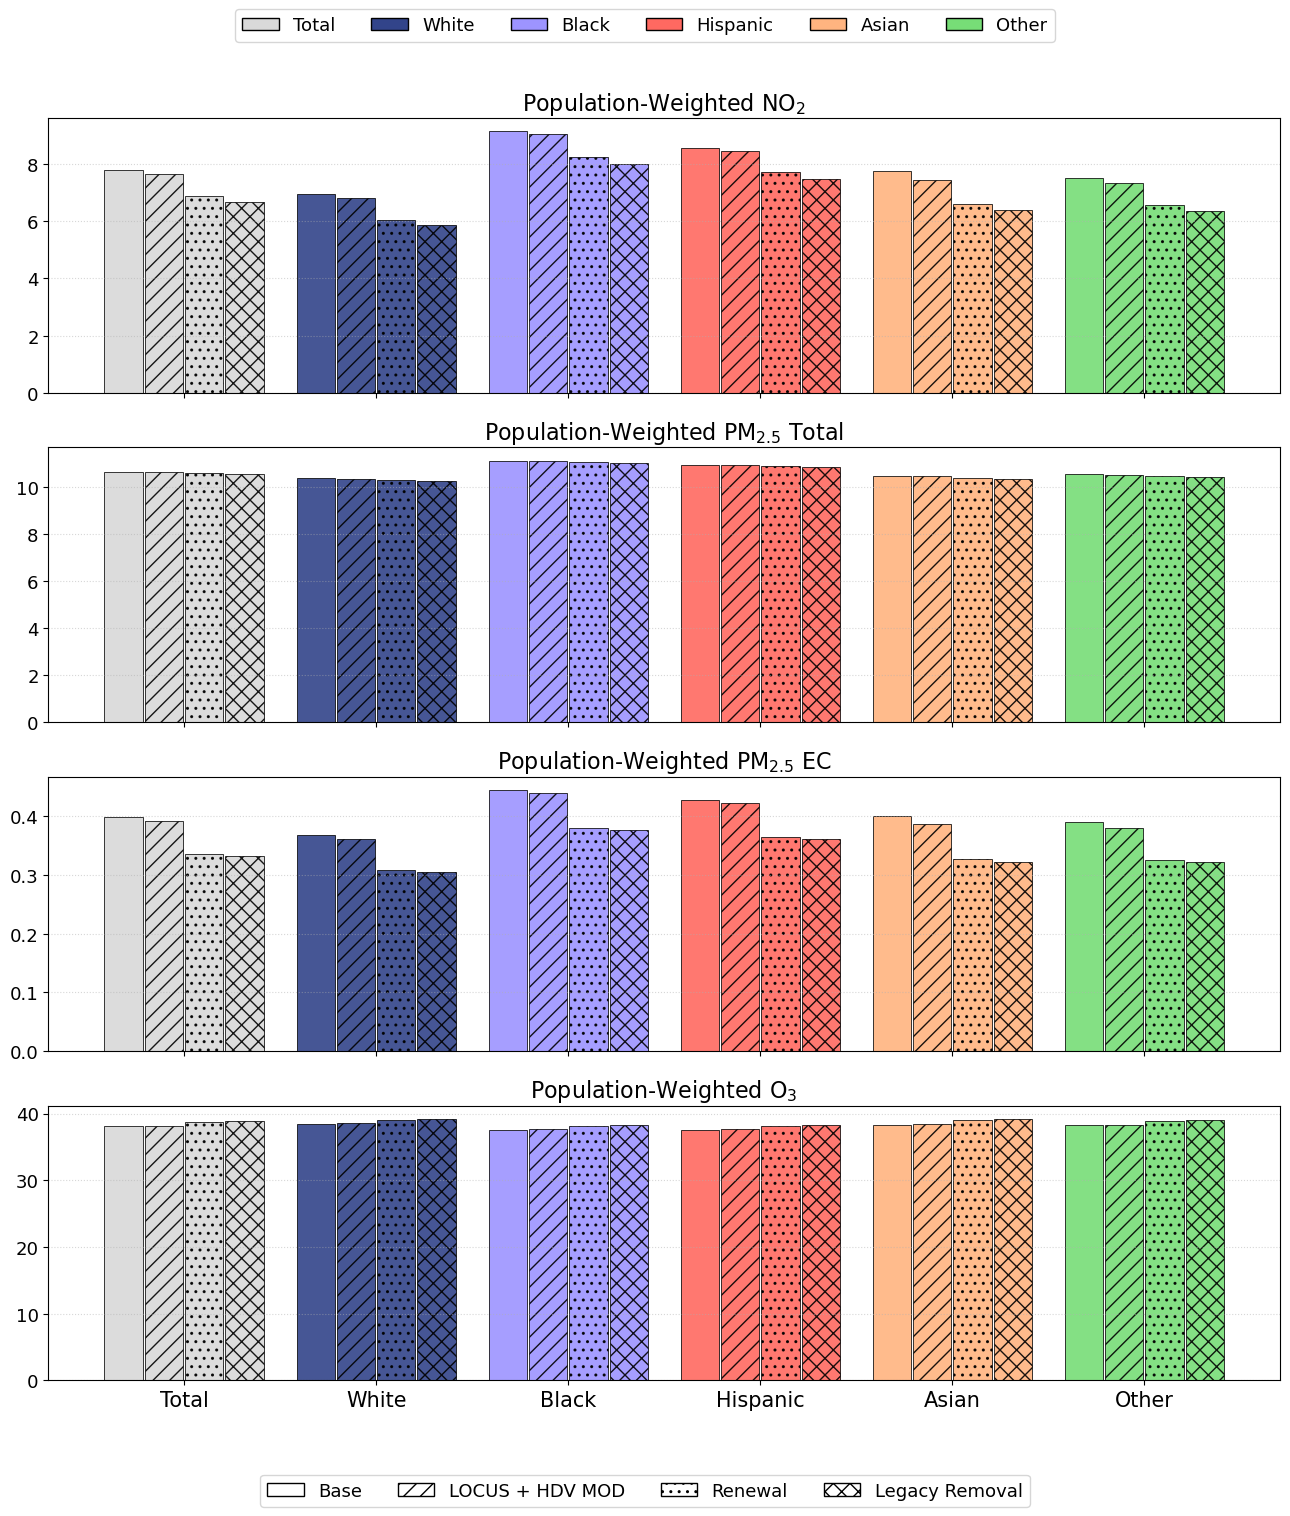

In [22]:
fig, axes = plt.subplots(4, 1, figsize=(13, 15), sharex=True)

x = np.arange(len(subgroups_for_plot))
cluster_w = 0.84
bar_w = cluster_w / len(scenario_keys)
offsets = (np.arange(len(scenario_keys)) - (len(scenario_keys) - 1) / 2) * bar_w

# --- NO2 ---
ax = axes[0]
for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups_for_plot):
        ax.bar(
            x[i] + offsets[s],
            no2_vals[s, i],
            width=bar_w * 0.95,
            color=colors_for_plot[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9
        )
ax.set_title("Population-Weighted NO$_2$", fontsize=16)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.tick_params(axis='y', labelsize=13)

# --- PM25 total ---
ax = axes[1]
for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups_for_plot):
        ax.bar(
            x[i] + offsets[s],
            pm25tot_vals[s, i],
            width=bar_w * 0.95,
            color=colors_for_plot[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9
        )
ax.set_title("Population-Weighted PM$_{2.5}$ Total", fontsize=16)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.tick_params(axis='y', labelsize=13)

# --- PM25 EC ---
ax = axes[2]
for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups_for_plot):
        ax.bar(
            x[i] + offsets[s],
            pm25ec_vals[s, i],
            width=bar_w * 0.95,
            color=colors_for_plot[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9
        )
ax.set_title("Population-Weighted PM$_{2.5}$ EC", fontsize=16)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.tick_params(axis='y', labelsize=13)

# --- O3 ---
ax = axes[3]
for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups_for_plot):
        ax.bar(
            x[i] + offsets[s],
            o3_vals[s, i],
            width=bar_w * 0.95,
            color=colors_for_plot[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9
        )
ax.set_title("Population-Weighted O$_3$", fontsize=16)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.tick_params(axis='y', labelsize=13)

axes[3].set_xticks(x)
axes[3].set_xticklabels(subgroups_for_plot, fontsize=15)

# ------------------------------------------------------------
# legends
# ------------------------------------------------------------
race_patches = [
    mpatches.Patch(facecolor=colors_for_plot[g], edgecolor="black", label=g)
    for g in subgroups_for_plot
]

scenario_patches = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatches[k],
        label=scenario_labels[i]
    )
    for i, k in enumerate(scenario_keys)
]

fig.legend(
    handles=race_patches,
    fontsize=13,
    loc="upper center",
    ncol=6,
    frameon=True,
    bbox_to_anchor=(0.5, 1.01)
)

fig.legend(
    handles=scenario_patches,
    fontsize=13,
    loc="lower center",
    ncol=4,
    frameon=True
)

plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

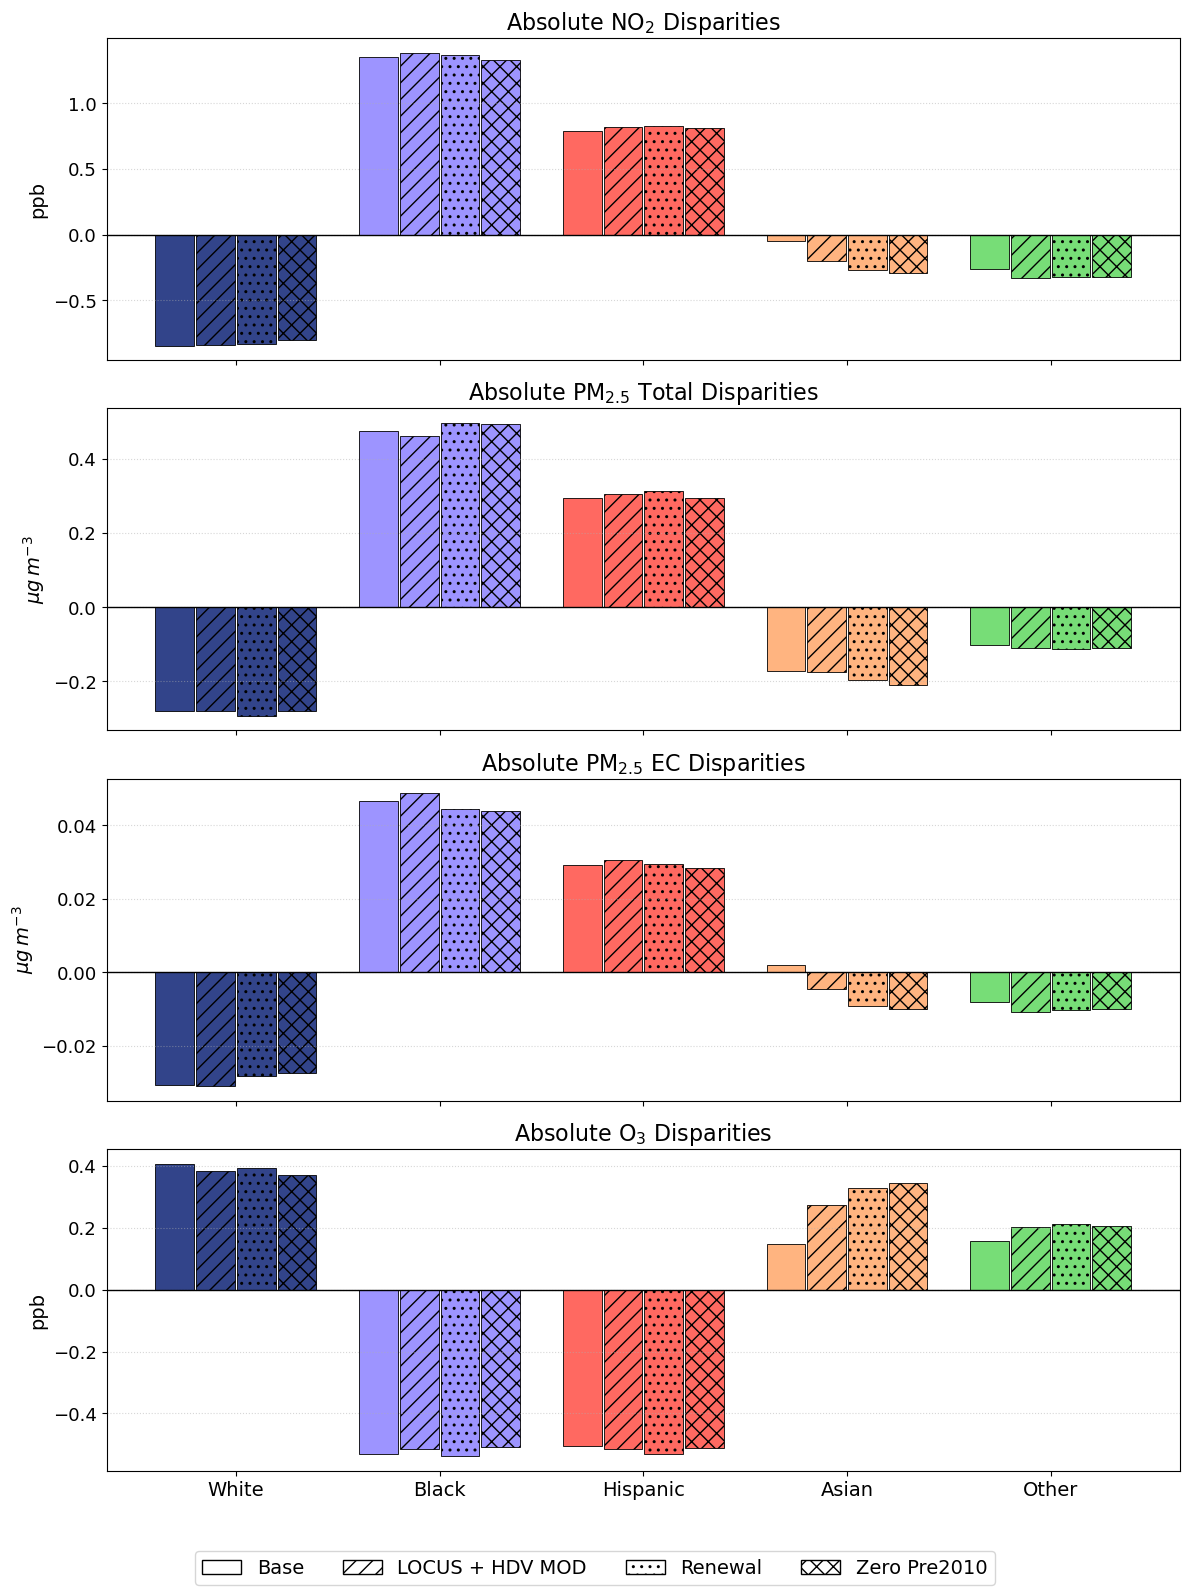

In [31]:
subgroups = ["White", "Black", "Hispanic", "Asian", "Other"]
scenario_keys = ["Base", "Idling", "Renewal", "LegacyRemoval"]
scenario_labels = ["Base", "LOCUS + HDV MOD", "Renewal", "Zero Pre2010"]

colors = {
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77",
}

hatches = {
    "Base": "",
    "Idling": "//",
    "Renewal": "..",
    "LegacyRemoval": "xx"
}

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

x = np.arange(len(subgroups))
cluster_w = 0.8
bar_w = cluster_w / len(scenario_keys)
offsets = (np.arange(len(scenario_keys)) - (len(scenario_keys)-1)/2) * bar_w

# ------------------------------------------------------------
# NO2 absolute Distributions
# ------------------------------------------------------------
ax = axes[0]

for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups):
        ax.bar(
            x[i] + offsets[s],
            no2_summary.loc[g, f"{key}_Absolute"],
            width=bar_w * 0.95,
            color=colors[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6
        )

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Absolute NO$_2$ Distributions", fontsize=16)
ax.set_ylabel("ppb", fontsize=14)
ax.tick_params(axis='y', labelsize=13)
ax.grid(axis="y", linestyle=":", alpha=0.5)

# ------------------------------------------------------------
# PM25_TOT absolute Distributions
# ------------------------------------------------------------
ax = axes[1]

for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups):
        ax.bar(
            x[i] + offsets[s],
            pm25_tot_summary.loc[g, f"{key}_Absolute"],
            width=bar_w * 0.95,
            color=colors[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6
        )

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Absolute PM$_{2.5}$ Total Distributions", fontsize=16)
ax.set_ylabel(r"$\mu g \, m^{-3}$", fontsize=14)
ax.tick_params(axis='y', labelsize=13)
ax.grid(axis="y", linestyle=":", alpha=0.5)

# ------------------------------------------------------------
# PM25_EC absolute Distributions
# ------------------------------------------------------------
ax = axes[2]

for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups):
        ax.bar(
            x[i] + offsets[s],
            pm25_ec_summary.loc[g, f"{key}_Absolute"],
            width=bar_w * 0.95,
            color=colors[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6
        )

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Absolute PM$_{2.5}$ EC Distributions", fontsize=16)
ax.set_ylabel(r"$\mu g \, m^{-3}$", fontsize=14)
ax.tick_params(axis='y', labelsize=13)
ax.grid(axis="y", linestyle=":", alpha=0.5)

# ------------------------------------------------------------
# O3 absolute Distributions
# ------------------------------------------------------------
ax = axes[3]

for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups):
        ax.bar(
            x[i] + offsets[s],
            O3_summary.loc[g, f"{key}_Absolute"],
            width=bar_w * 0.95,
            color=colors[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6
        )

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Absolute O$_3$ Distributions", fontsize=16)
ax.set_ylabel("ppb", fontsize=14)
ax.tick_params(axis='y', labelsize=13)
ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[3].set_xticks(x)
axes[3].set_xticklabels(subgroups, fontsize=14)

scenario_patches = [
    mpatches.Patch(facecolor="white", edgecolor="black", hatch=hatches[k], label=scenario_labels[i])
    for i, k in enumerate(scenario_keys)
]

fig.legend(
    handles=scenario_patches,
    loc="lower center",
    ncol=4,
    fontsize=14,
    frameon=True
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('July2023ConcentrationsAbsoluteDistributions.pdf')
plt.show()

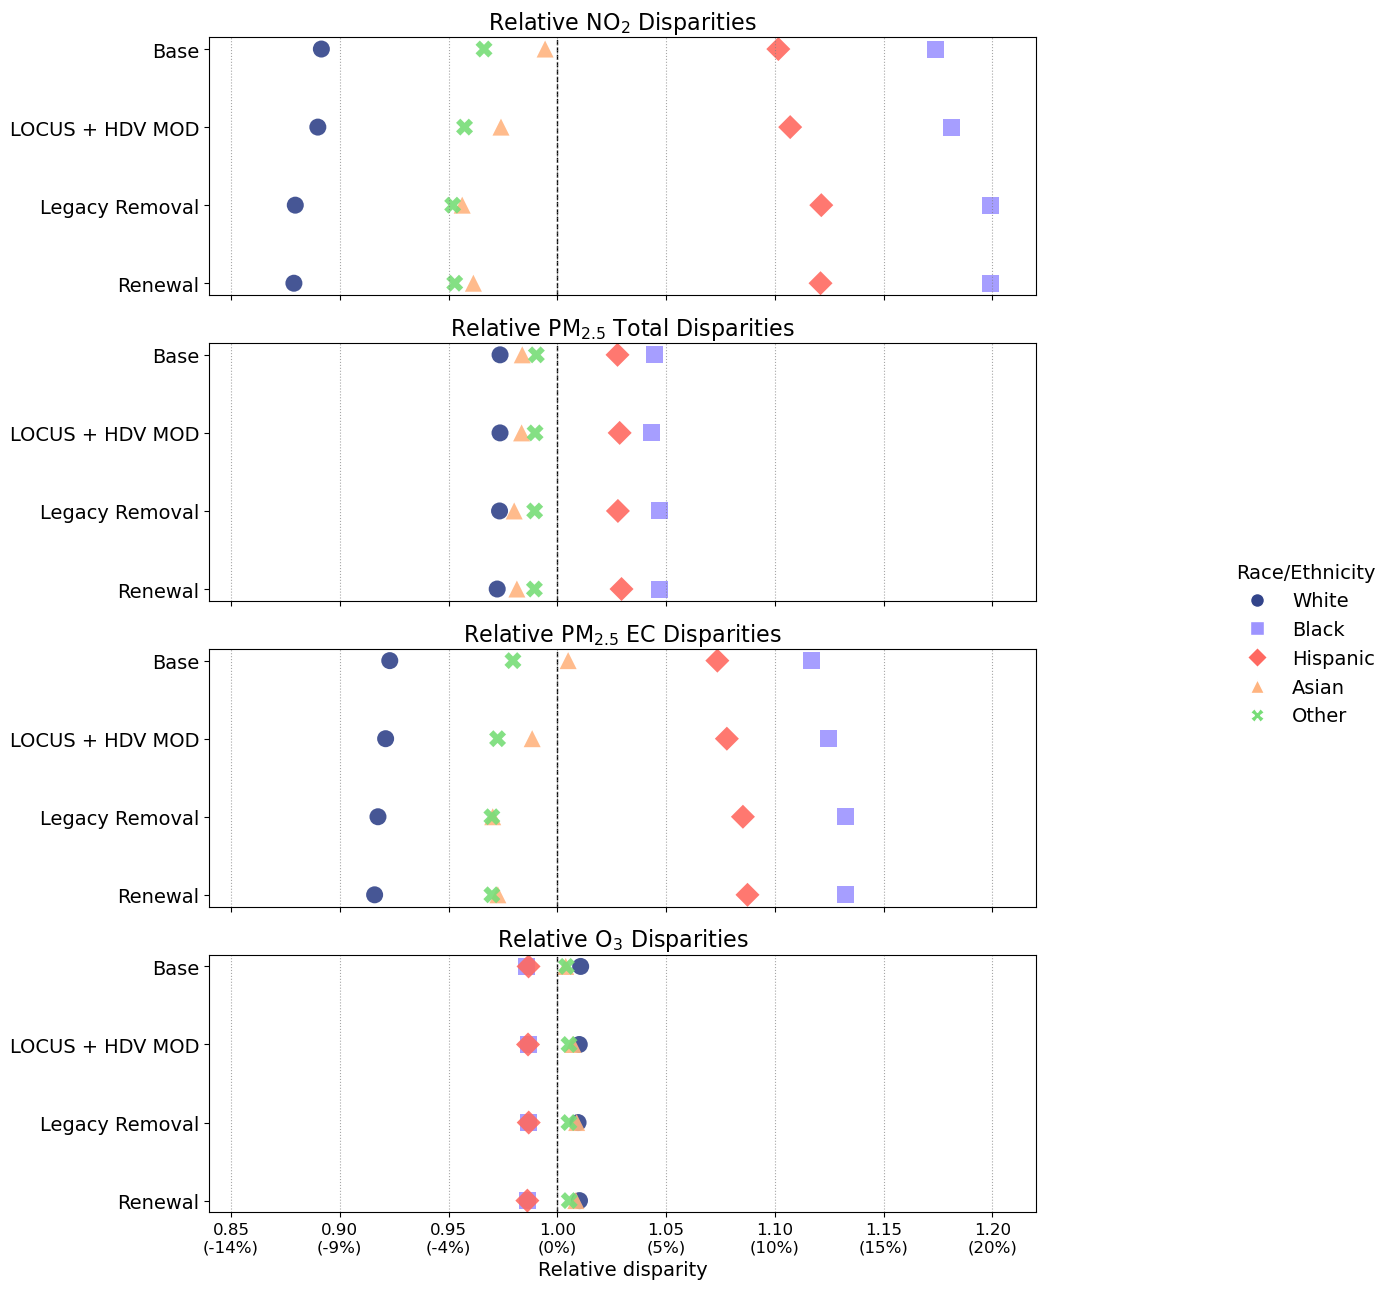

In [30]:
# ============================================================
# RELATIVE Distributions (UPDATED AXIS: 0.90–1.20)
# ============================================================

subgroups = ["White", "Black", "Hispanic", "Asian", "Other"]

markers = {
    "White": "o",
    "Black": "s",
    "Hispanic": "D",
    "Asian": "^",
    "Other": "X",
}

colors = {
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77",
}

xticks = np.arange(0.80, 1.201, 0.05)
xtick_labels = [f"{x:.2f}\n({int((x-1)*100)}%)" for x in xticks]

fig, axes = plt.subplots(4, 1, figsize=(12, 13), sharex=True)

# ------------------------------------------------------------
# helper function to avoid repetition
# ------------------------------------------------------------
def plot_panel(ax, rows, title):
    ypos = np.arange(len(rows))

    for j, (row_label, tbl, key) in enumerate(rows):
        for g in subgroups:
            x_val = tbl.loc[g, f"{key}_Relative"]

            ax.scatter(
                x_val, j,
                s=150,
                marker=markers[g],
                color=colors[g],
                alpha=0.9,
                edgecolor="none"
            )

    ax.set_yticks(ypos)
    ax.set_yticklabels([r[0] for r in rows], fontsize=14)
    ax.set_title(title, fontsize=16)

    ax.axvline(1.0, color="k", linestyle="--", linewidth=1)

    for xv in xticks:
        if xv != 1.0:
            ax.axvline(xv, color="grey", linestyle=":", linewidth=0.8, alpha=0.7)

# ------------------------------------------------------------
# NO2
# ------------------------------------------------------------
rows_no2 = [
    ("Renewal", no2_summary, "Renewal"),
    ("Legacy Removal", no2_summary, "LegacyRemoval"),
    ("LOCUS + HDV MOD", no2_summary, "Idling"),
    ("Base", no2_summary, "Base"),
]
plot_panel(axes[0], rows_no2, "Relative NO$_2$ Distributions")

# ------------------------------------------------------------
# PM25_TOT
# ------------------------------------------------------------
rows_pm25tot = [
    ("Renewal", pm25_tot_summary, "Renewal"),
    ("Legacy Removal", pm25_tot_summary, "LegacyRemoval"),
    ("LOCUS + HDV MOD", pm25_tot_summary, "Idling"),
    ("Base", pm25_tot_summary, "Base"),
]
plot_panel(axes[1], rows_pm25tot, "Relative PM$_{2.5}$ Total Distributions")

# ------------------------------------------------------------
# PM25_EC
# ------------------------------------------------------------
rows_pm25ec = [
    ("Renewal", pm25_ec_summary, "Renewal"),
    ("Legacy Removal", pm25_ec_summary, "LegacyRemoval"),
    ("LOCUS + HDV MOD", pm25_ec_summary, "Idling"),
    ("Base", pm25_ec_summary, "Base"),
]
plot_panel(axes[2], rows_pm25ec, "Relative PM$_{2.5}$ EC Distributions")

# ------------------------------------------------------------
# O3
# ------------------------------------------------------------
rows_o3 = [
    ("Renewal", O3_summary, "Renewal"),
    ("Legacy Removal", O3_summary, "LegacyRemoval"),
    ("LOCUS + HDV MOD", O3_summary, "Idling"),
    ("Base", O3_summary, "Base"),
]
plot_panel(axes[3], rows_o3, "Relative O$_3$ Distributions")

# ------------------------------------------------------------
# x-axis formatting
# ------------------------------------------------------------
axes[3].set_xticks(xticks)
axes[3].set_xticklabels(xtick_labels, fontsize=12)
axes[3].set_xlim(0.84, 1.22)
axes[3].set_xlabel("Relative disparity", fontsize=14)

# ------------------------------------------------------------
# legend
# ------------------------------------------------------------
legend_handles = [
    Line2D([0],[0], marker=markers[g], color="w",
           markerfacecolor=colors[g],
           markersize=10,
           label=g)
    for g in subgroups
]

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02,0.5),
    frameon=False,
    title="Race/Ethnicity",
    title_fontsize=14,
    fontsize=14
)

plt.tight_layout(rect=[0,0,0.88,1])
plt.savefig('July2023ConcentrationsRelativeDistributions.pdf')
plt.show()